# Phần 2: Trực quan hóa & Phân tích dữ liệu

### Mục lục
| STT | Chủ đề | Cấp độ phân tích |
|-----|--------|-----------------|
| 1   | Tổng quan Doanh thu & Lợi nhuận | Descriptive |
| 2   | Tính mùa vụ & Xu hướng | Descriptive + Predictive |
| 3   | Phân tích Khách hàng & Phân khúc | Diagnostic |
| 4   | Hiệu quả Khuyến mãi | Diagnostic + Prescriptive |
| 5   | Trả hàng & Chất lượng dịch vụ | Diagnostic |
| 6   | Kênh bán hàng & Web Traffic | Diagnostic + Predictive |
| 7   | Tồn kho & Chuỗi cung ứng | Diagnostic + Prescriptive |
| 8   | Phân tích Địa lý | Descriptive + Prescriptive |
| 9   | Tổng hợp & Đề xuất chiến lược | Prescriptive |

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#2CA58D', 'danger': '#E63946', 'dark': '#1D3557', 'light': '#A8DADC',
    'purple': '#7B2D8E', 'teal': '#17A2B8', 'gold': '#FFC107'
}
PAL = list(COLORS.values())

def fmt_vnd(x, pos=None):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    elif abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    elif abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

In [2]:
# Load all datasets
sales      = pd.read_csv('data/sales.csv', parse_dates=['Date'])
orders     = pd.read_csv('data/orders.csv', parse_dates=['order_date'])
order_items= pd.read_csv('data/order_items.csv')
products   = pd.read_csv('data/products.csv')
customers  = pd.read_csv('data/customers.csv', parse_dates=['signup_date'])
payments   = pd.read_csv('data/payments.csv')
shipments  = pd.read_csv('data/shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns    = pd.read_csv('data/returns.csv', parse_dates=['return_date'])
reviews    = pd.read_csv('data/reviews.csv', parse_dates=['review_date'])
promotions = pd.read_csv('data/promotions.csv', parse_dates=['start_date', 'end_date'])
geography  = pd.read_csv('data/geography.csv')
inventory  = pd.read_csv('data/inventory.csv', parse_dates=['snapshot_date'])
web_traffic= pd.read_csv('data/web_traffic.csv', parse_dates=['date'])

print('=== Dataset Shapes ===')
for name, df in [('sales', sales), ('orders', orders), ('order_items', order_items),
                  ('products', products), ('customers', customers), ('payments', payments),
                  ('shipments', shipments), ('returns', returns), ('reviews', reviews),
                  ('promotions', promotions), ('geography', geography), ('inventory', inventory),
                  ('web_traffic', web_traffic)]:
    print(f'  {name:15s}: {df.shape[0]:>8,} rows × {df.shape[1]:>2} cols')

=== Dataset Shapes ===
  sales          :    3,833 rows ×  3 cols
  orders         :  646,945 rows ×  8 cols
  order_items    :  714,669 rows ×  7 cols
  products       :    2,412 rows ×  8 cols
  customers      :  121,930 rows ×  7 cols
  payments       :  646,945 rows ×  4 cols
  shipments      :  566,067 rows ×  4 cols
  returns        :   39,939 rows ×  7 cols
  reviews        :  113,551 rows ×  7 cols
  promotions     :       50 rows × 10 cols
  geography      :   39,948 rows ×  4 cols
  inventory      :   60,247 rows × 17 cols
  web_traffic    :    3,652 rows ×  7 cols


## 1. Tổng quan Doanh thu & Lợi nhuận *(Descriptive + Diagnostic)*

> **Câu hỏi:** Doanh thu và chi phí đã thay đổi như thế nào qua 10 năm? Biên lợi nhuận gộp có ổn định không?

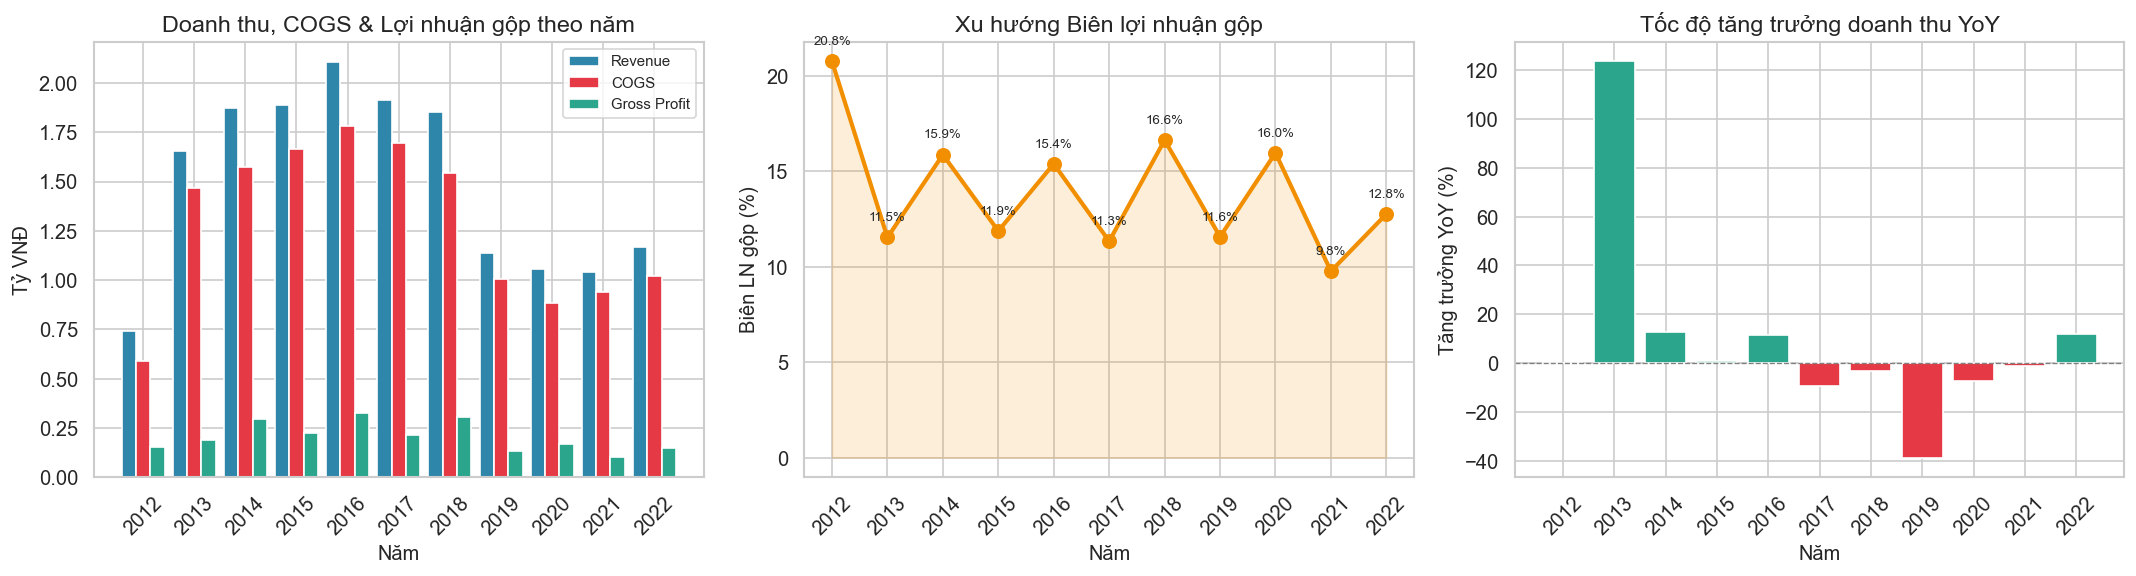


📊 TÓM TẮT 10+ NĂM HOẠT ĐỘNG
  Tổng doanh thu tích lũy : 16.4 tỷ VNĐ
  Tổng lợi nhuận gộp      : 2.3 tỷ VNĐ
  Biên LN gộp trung bình  : 14.0%
  Tăng trưởng DT TB/năm   : 10.2%
  Năm DT cao nhất         : 2016
  Năm tăng trưởng mạnh nhất: 2013 (123.5%)


In [6]:
# === Tính các chỉ số theo năm ===
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['Gross_Profit'] = sales['Revenue'] - sales['COGS']
sales['Margin_pct'] = sales['Gross_Profit'] / sales['Revenue'] * 100

annual = sales.groupby('year').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum'),
    Gross_Profit=('Gross_Profit', 'sum'),
    Days=('Date', 'count')
).reset_index()
annual['Margin_pct'] = annual['Gross_Profit'] / annual['Revenue'] * 100
annual['Rev_YoY'] = annual['Revenue'].pct_change() * 100
annual['Rev_per_day'] = annual['Revenue'] / annual['Days']

# --- Chart 1: Revenue, COGS, Gross Profit by Year ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
x = annual['year']
w = 0.28
axes[0].bar(x - w, annual['Revenue']/1e9, w, label='Revenue', color=COLORS['primary'])
axes[0].bar(x, annual['COGS']/1e9, w, label='COGS', color=COLORS['danger'])
axes[0].bar(x + w, annual['Gross_Profit']/1e9, w, label='Gross Profit', color=COLORS['success'])
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Tỷ VNĐ')
axes[0].set_title('Doanh thu, COGS & Lợi nhuận gộp theo năm')
axes[0].legend(fontsize=9)
axes[0].set_xticks(x)
axes[0].tick_params(axis='x', rotation=45)

# Margin % trend
axes[1].plot(annual['year'], annual['Margin_pct'], 'o-', color=COLORS['accent'], linewidth=2.5, markersize=8)
axes[1].fill_between(annual['year'], annual['Margin_pct'], alpha=0.15, color=COLORS['accent'])
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Biên LN gộp (%)')
axes[1].set_title('Xu hướng Biên lợi nhuận gộp')
axes[1].set_xticks(x)
axes[1].tick_params(axis='x', rotation=45)
for _, row in annual.iterrows():
    axes[1].annotate(f"{row['Margin_pct']:.1f}%", (row['year'], row['Margin_pct']),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

# YoY Growth
colors_yoy = [COLORS['success'] if v >= 0 else COLORS['danger'] for v in annual['Rev_YoY'].fillna(0)]
axes[2].bar(annual['year'], annual['Rev_YoY'].fillna(0), color=colors_yoy)
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Năm')
axes[2].set_ylabel('Tăng trưởng YoY (%)')
axes[2].set_title('Tốc độ tăng trưởng doanh thu YoY')
axes[2].set_xticks(x)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary stats
total_rev = annual['Revenue'].sum()
avg_margin = annual['Margin_pct'].mean()
avg_yoy = annual['Rev_YoY'].dropna().mean()
print(f"\n{'='*50}")
print(f"📊 TÓM TẮT 10+ NĂM HOẠT ĐỘNG")
print(f"{'='*50}")
print(f"  Tổng doanh thu tích lũy : {total_rev/1e9:.1f} tỷ VNĐ")
print(f"  Tổng lợi nhuận gộp      : {annual['Gross_Profit'].sum()/1e9:.1f} tỷ VNĐ")
print(f"  Biên LN gộp trung bình  : {avg_margin:.1f}%")
print(f"  Tăng trưởng DT TB/năm   : {avg_yoy:.1f}%")
print(f"  Năm DT cao nhất         : {annual.loc[annual['Revenue'].idxmax(), 'year']}")
print(f"  Năm tăng trưởng mạnh nhất: {annual.loc[annual['Rev_YoY'].idxmax(), 'year']} ({annual['Rev_YoY'].max():.1f}%)")

### 📝 Phân tích — Section 1

**Mô tả:** Ba biểu đồ trên cho thấy toàn cảnh tài chính qua từng năm: doanh thu vs chi phí, biên lợi nhuận gộp, và tốc độ tăng trưởng.

**Key Findings:**
- **Tổng doanh thu tích lũy đạt 16.4 tỷ VNĐ** trong hơn 10 năm hoạt động, với tổng lợi nhuận gộp 2.3 tỷ VNĐ.
- **Biên lợi nhuận gộp trung bình 14.0%** — mức khá thấp cho ngành thời trang, cho thấy chi phí vốn hàng bán (COGS) chiếm tỷ trọng lớn.
- **Tăng trưởng TB 10.2%/năm**, với năm 2013 tăng trưởng đột biến 123.5% (giai đoạn đầu mở rộng). Năm doanh thu cao nhất là 2016.
- Sau giai đoạn tăng trưởng nhanh ban đầu, tốc độ tăng trưởng có xu hướng chậm lại → doanh nghiệp đang bước vào giai đoạn trưởng thành.

**Business Implication:**
- Biên LN gộp 14% là mức cần cải thiện. Cần xem xét: (1) đàm phán lại giá nhập, (2) tăng tỷ trọng sản phẩm margin cao, (3) tối ưu mix sản phẩm.
- Tăng trưởng chậm lại sau 2016 → cần tìm động lực tăng trưởng mới (mở rộng thị trường, sản phẩm mới, kênh bán mới).

## 2. Phân tích Tính mùa vụ & Xu hướng *(Descriptive + Predictive)*

> **Câu hỏi:** Doanh thu có pattern mùa vụ rõ ràng không? Tháng nào, ngày nào bán tốt nhất? Xu hướng dài hạn ra sao?

## 3. Phân tích Khách hàng & Phân khúc *(Diagnostic)*

> **Câu hỏi:** Nhóm khách hàng nào đóng góp nhiều nhất? Tỷ lệ khách mua lại? Hành vi mua hàng khác nhau giữa các phân khúc?

## 4. Hiệu quả Khuyến mãi *(Diagnostic + Prescriptive)*

> **Câu hỏi:** Chương trình khuyến mãi nào hiệu quả nhất? Mức giảm giá tối ưu là bao nhiêu? Khuyến mãi có thực sự tăng doanh thu?

## 5. Phân tích Trả hàng & Chất lượng dịch vụ *(Diagnostic)*

> **Câu hỏi:** Tỷ lệ trả hàng bao nhiêu? Lý do trả hàng chính? Sản phẩm/category nào bị trả nhiều nhất? Thời gian giao hàng ảnh hưởng thế nào?

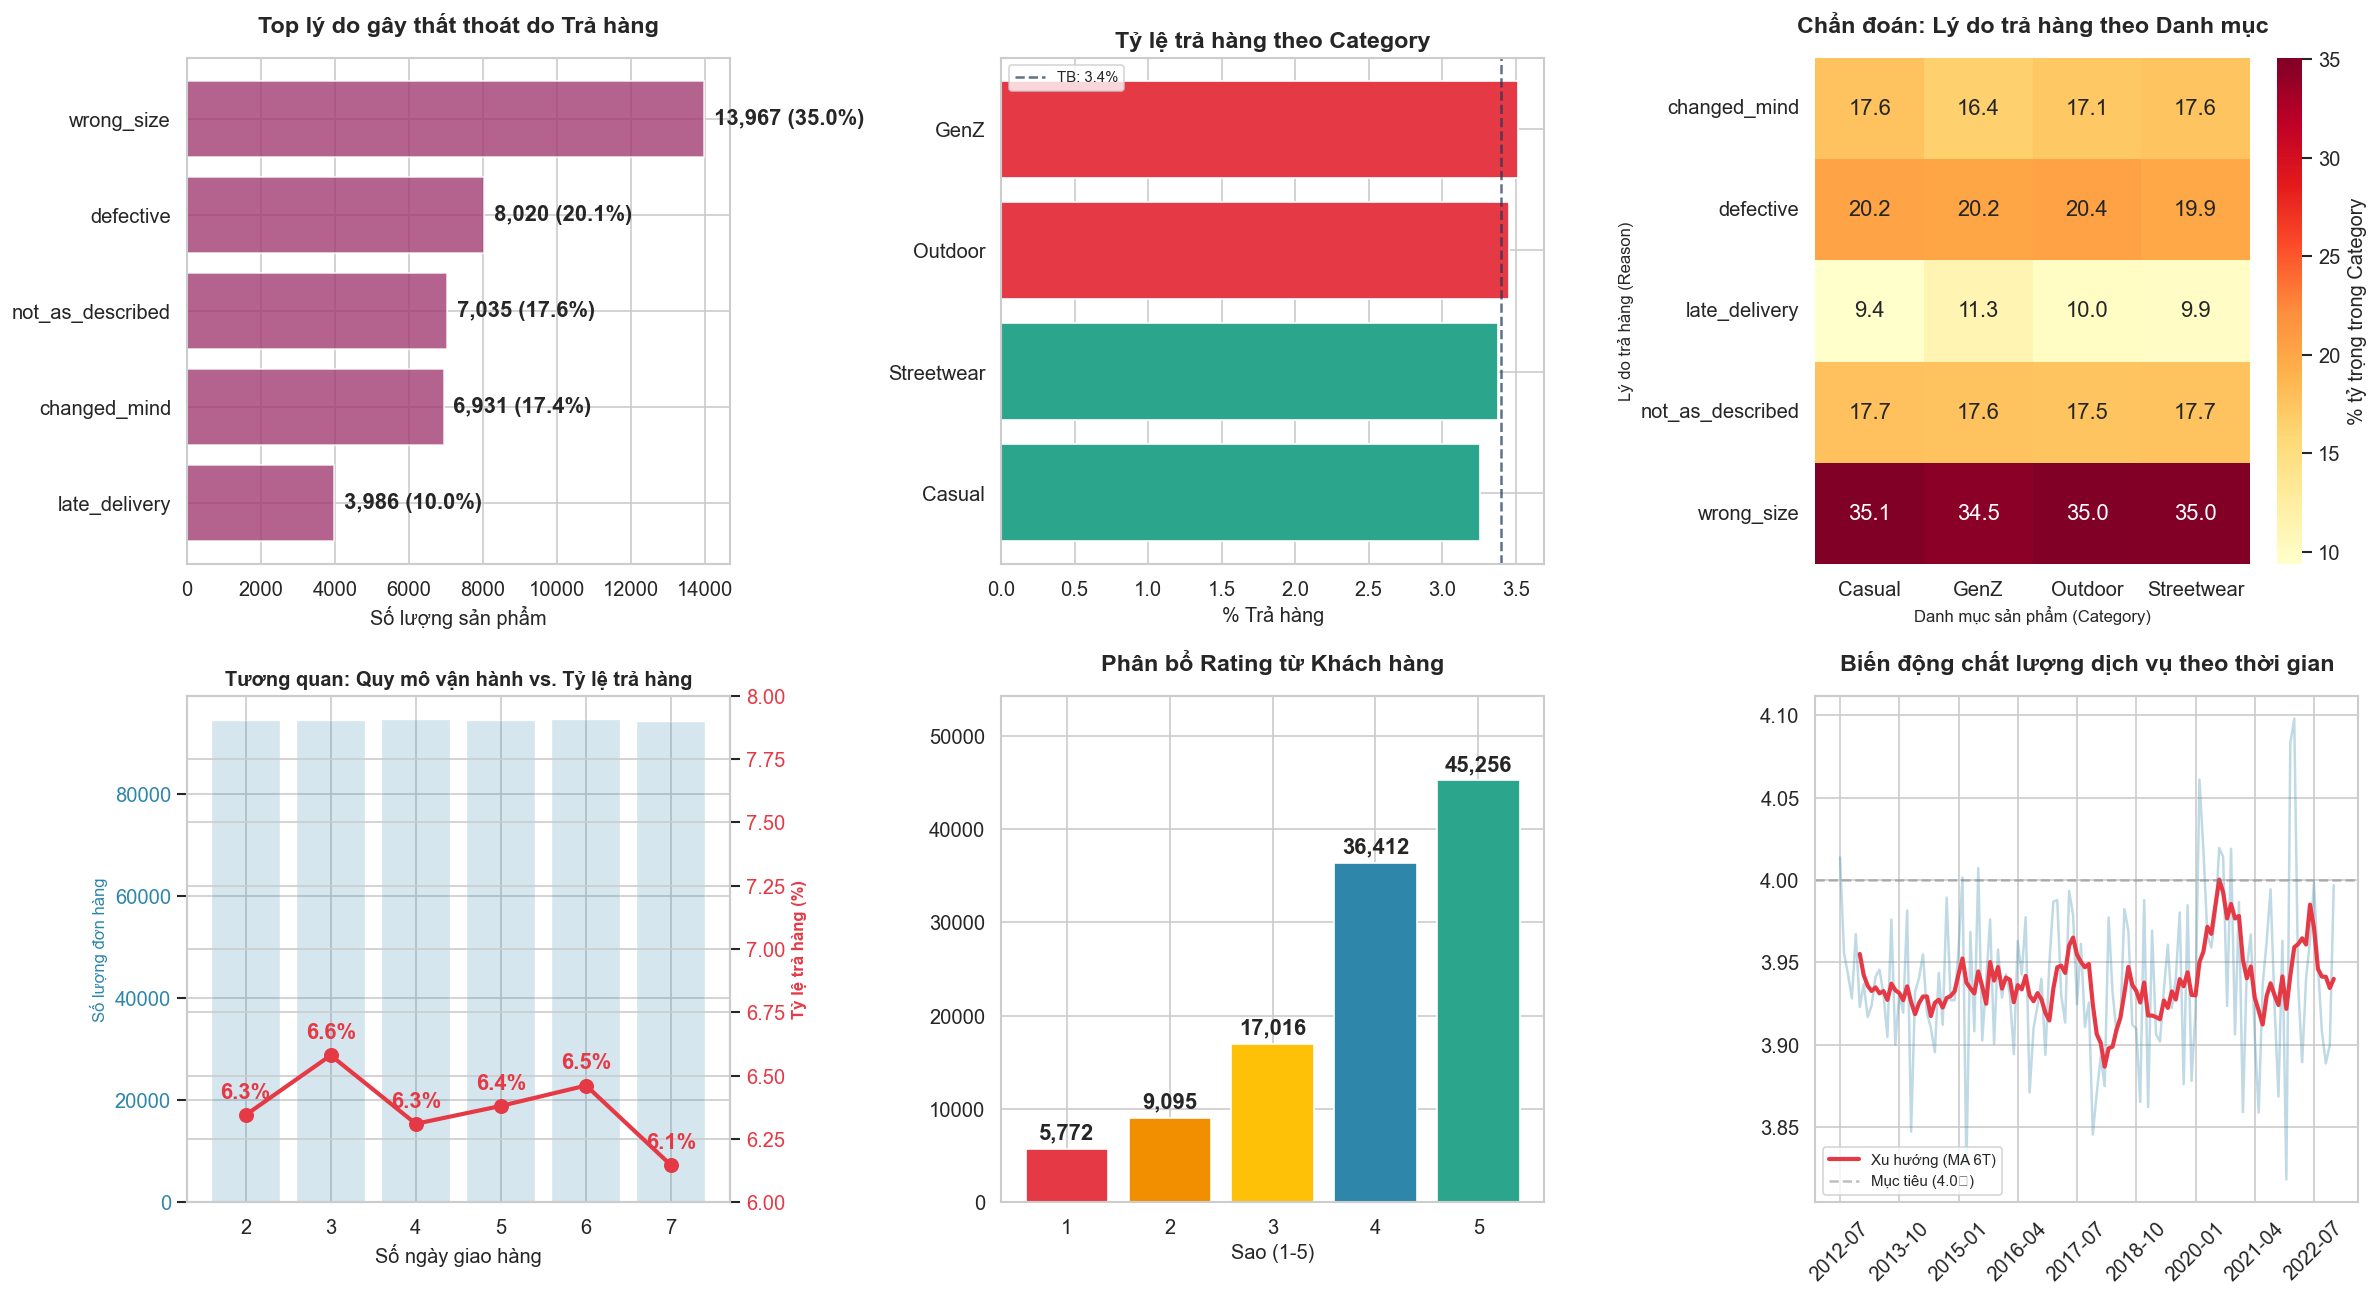


📦 RETURNS & SERVICE QUALITY
  Tổng SL trả hàng      : 109,586 sản phẩm
  Tỷ lệ trả hàng tổng   : 3.4%
  Tổng hoàn tiền         : 0.51 tỷ VNĐ
  Thời gian giao TB      : 4.5 ngày
  Rating TB              : 3.94/5.0
  Lý do trả hàng #1     : wrong_size (35.0%)


In [10]:
# Returns analysis
returns_detail = returns.merge(products[['product_id', 'category', 'segment', 'price']], on='product_id', how='left')
returns_detail = returns_detail.merge(orders[['order_id', 'order_date']], on='order_id', how='left')

# Shipment analysis
ship_detail = shipments.copy()
ship_detail['delivery_days'] = (ship_detail['delivery_date'] - ship_detail['ship_date']).dt.days

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Return reasons
reason_stats = returns_detail['return_reason'].value_counts().sort_values(ascending=True)
axes[0,0].barh(reason_stats.index, reason_stats.values, color=COLORS['secondary'], alpha=0.8)
for i, v in enumerate(reason_stats.values):
    axes[0,0].text(v + 100, i, f' {v:,} ({v/reason_stats.sum()*100:.1f}%)', va='center', fontweight='bold')
axes[0,0].set_title('Top lý do gây thất thoát do Trả hàng', fontsize=14, fontweight='bold', pad=15)
axes[0,0].set_xlabel('Số lượng sản phẩm')

# 2. Return rate by category
total_items_cat = order_items.merge(products[['product_id', 'category']], on='product_id')
total_by_cat = total_items_cat.groupby('category')['quantity'].sum()
return_by_cat = returns_detail.groupby('category')['return_quantity'].sum()
return_rate_cat = (return_by_cat / total_by_cat * 100).sort_values(ascending=True).dropna()
colors_rr = [COLORS['danger'] if v > return_rate_cat.mean() else COLORS['success'] for v in return_rate_cat]
axes[0,1].barh(return_rate_cat.index, return_rate_cat.values, color=colors_rr, edgecolor='white')
axes[0,1].axvline(return_rate_cat.mean(), color=COLORS['dark'], linestyle='--', alpha=0.7,
                  label=f'TB: {return_rate_cat.mean():.1f}%')
axes[0,1].set_title('Tỷ lệ trả hàng theo Category', fontweight='bold')
axes[0,1].set_xlabel('% Trả hàng'); axes[0,1].legend(fontsize=9)

# 3. Delivery time distribution
reason_cat_pivot = pd.crosstab(returns_detail['return_reason'], returns_detail['category'])
reason_cat_pct = reason_cat_pivot.div(reason_cat_pivot.sum(axis=0), axis=1) * 100
sns.heatmap(reason_cat_pct,
            annot=True,
            fmt=".1f",
            cmap='YlOrRd',
            ax=axes[0,2],
            cbar_kws={'label': '% tỷ trọng trong Category'})
axes[0,2].set_title('Chẩn đoán: Lý do trả hàng theo Danh mục', fontsize=14, fontweight='bold', pad=15)
axes[0,2].tick_params(axis='x', rotation=0) # Cho các Category nằm ngang
axes[0,2].tick_params(axis='y', rotation=0) # Cho các Lý do nằm ngang
axes[0,2].set_xlabel('Danh mục sản phẩm (Category)', fontsize=10)
axes[0,2].set_ylabel('Lý do trả hàng (Reason)', fontsize=10)

# 4. Return rate by delivery time bucket
all_orders_ship = orders.merge(shipments[['order_id', 'ship_date', 'delivery_date']], on='order_id', how='inner')
all_orders_ship['delivery_days'] = (all_orders_ship['delivery_date'] - all_orders_ship['ship_date']).dt.days
returned_orders = set(returns['order_id'].unique())
all_orders_ship['is_returned'] = all_orders_ship['order_id'].isin(returned_orders)

bucket_stats = all_orders_ship.groupby('delivery_days').agg(
    total_orders=('order_id', 'count'),
    return_rate=('is_returned', 'mean')
)
bucket_stats['return_rate'] *= 100

ax1 = axes[1,0]
ax2 = ax1.twinx()

ax1.bar(bucket_stats.index.astype(str), bucket_stats['total_orders'],
        color=COLORS['primary'], alpha=0.2, label='Số lượng đơn hàng')
ax1.set_ylabel('Số lượng đơn hàng', color=COLORS['primary'], fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLORS['primary'])

ax2.plot(bucket_stats.index.astype(str), bucket_stats['return_rate'],
         color=COLORS['danger'], marker='o', linewidth=2.5, markersize=8, label='Tỷ lệ trả hàng (%)')
ax2.set_ylabel('Tỷ lệ trả hàng (%)', color=COLORS['danger'], fontsize=10, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=COLORS['danger'])
ax2.set_ylim(6.0, 8.0)

for i, val in enumerate(bucket_stats['return_rate']):
    ax2.annotate(f'{val:.1f}%', (i, val), xytext=(0, 10),
                 textcoords='offset points', ha='center', color=COLORS['danger'], fontweight='bold')

ax1.set_title('Tương quan: Quy mô vận hành vs. Tỷ lệ trả hàng', fontsize=12, fontweight='bold')
ax1.set_xlabel('Số ngày giao hàng')


# 5. Review rating distribution
rating_dist = reviews['rating'].value_counts().sort_index()
colors_rating = [COLORS['danger'], COLORS['accent'], COLORS['gold'], COLORS['primary'], COLORS['success']]
bars = axes[1,1].bar(rating_dist.index, rating_dist.values, color=colors_rating, edgecolor='white')
for bar in bars:
    axes[1,1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000, f'{bar.get_height():,}', ha='center', fontweight='bold')
axes[1,1].set_title('Phân bổ Rating từ Khách hàng', fontsize=14, fontweight='bold', pad=15)
axes[1,1].set_xlabel('Sao (1-5)'); axes[1,1].set_ylim(0, rating_dist.max()*1.2)

# 6. Rating trend over time
reviews['year_month'] = reviews['review_date'].dt.to_period('M')
rating_trend = reviews.groupby('year_month')['rating'].mean()
axes[1,2].plot(rating_trend.index.astype(str), rating_trend.values, color=COLORS['primary'], alpha=0.3)
rating_ma = rating_trend.rolling(6).mean()
axes[1,2].plot(rating_trend.index.astype(str), rating_ma.values, color=COLORS['danger'], linewidth=2.5, label='Xu hướng (MA 6T)')
axes[1,2].axhline(y=4.0, color='gray', linestyle='--', alpha=0.5, label='Mục tiêu (4.0⭐)')
axes[1,2].set_title('Biến động chất lượng dịch vụ theo thời gian', fontsize=14, fontweight='bold', pad=15)
axes[1,2].legend(loc='lower left', fontsize=9)
tick_positions = range(0, len(rating_trend), max(1, len(rating_trend)//8))
axes[1,2].set_xticks([rating_trend.index.astype(str)[i] for i in tick_positions])
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

# Summary
total_returned = returns['return_quantity'].sum()
total_sold = order_items['quantity'].sum()
total_refund = returns['refund_amount'].sum()
print(f"\n{'='*50}")
print(f"📦 RETURNS & SERVICE QUALITY")
print(f"{'='*50}")
print(f"  Tổng SL trả hàng      : {total_returned:,} sản phẩm")
print(f"  Tỷ lệ trả hàng tổng   : {total_returned/total_sold*100:.1f}%")
print(f"  Tổng hoàn tiền         : {total_refund/1e9:.2f} tỷ VNĐ")
print(f"  Thời gian giao TB      : {avg_delivery:.1f} ngày")
print(f"  Rating TB              : {avg_rating:.2f}/5.0")
print(f"  Lý do trả hàng #1     : {reason_counts.index[0]} ({reason_counts.iloc[0]/reason_counts.sum()*100:.1f}%)")